# Computer Exercise 9.2 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **챕터**: 9. The Method of Least Squares
> **절**: §9.2 Orthogonal Systems and Chebyshev Polynomials — *체비쇼프 근사 / minimax / 경제화*
> **풀이 일자**: Day 35
> **언어**: Python 3 (NumPy / SciPy / Pandas / Matplotlib)

## 1. 문제 (원문)

> **2.** For $f(x)=e^{x}$ on $[-1,1]$, compare the **truncated Taylor (Maclaurin) polynomial** of degree $n$ with the
> **truncated Chebyshev series** of the same degree. Plot the error curves and report the maximum (sup-norm) error of each.
> Then perform **Chebyshev economization**: starting from a high-degree Taylor polynomial, remove the leading Chebyshev
> components one at a time and watch how the maximum error grows, demonstrating that the Chebyshev truncation is
> *near-minimax*.

### 한국어 풀이용 정리
$f(x)=e^x$ 를 $[-1,1]$ 에서 (i) 차수 $n$ **테일러(매클로린) 다항식**, (ii) 같은 차수 **체비쇼프 급수 절단**으로
근사하고 오차 곡선과 최대오차(sup-노름)를 비교한다. 이어서 **체비쇼프 경제화**를 수행한다: 고차 테일러
다항식을 체비쇼프 기저로 펼친 뒤 가장 높은 항부터 하나씩 제거하며 최대오차의 증가를 관찰한다. 이로써 체비쇼프
절단이 **near-minimax**(거의 최소·최대) 임을 확인한다.

## 2. 수학적 배경

### 2.1 체비쇼프 다항식
$T_n(x)=\cos(n\arccos x)$ 는 가중치 $w(x)=1/\sqrt{1-x^2}$ 에 대해 직교하며 $|T_n(x)|\le 1$ 이고 $[-1,1]$ 에서
$n+1$ 개의 극점에서 $\pm1$ 을 번갈아 취한다(**equioscillation**).

### 2.2 minimax 성질 (단항 최고차항 최소화)
모든 모닉(monic) $n$차 다항식 중 $\sup$-노름이 가장 작은 것은
$$\boxed{\;\tilde T_n(x)=2^{-(n-1)}T_n(x),\qquad \max_{[-1,1]}|\tilde T_n|=2^{-(n-1)}\;}$$
이다. 이 *작은 끝점 행동* 때문에 체비쇼프 절단오차는 구간 전체에 **균등하게** 퍼진다 — 테일러가 $x=\pm1$ 에서
오차를 몰아주는 것과 대조된다.

### 2.3 체비쇼프 급수와 near-minimax
$f(x)=\tfrac{a_0}{2}+\sum_{k\ge1}a_kT_k(x),\quad a_k=\dfrac{2}{\pi}\!\int_{-1}^{1}\dfrac{f(x)T_k(x)}{\sqrt{1-x^2}}dx.$
매끄러운 $f$ 는 $a_k$ 가 빠르게 감소하므로, 급수를 차수 $n$ 에서 자른 오차는 대략 $|a_{n+1}|$ 로 지배되고
이는 진짜 최선(minimax) 다항식 오차에 매우 가깝다.

### 2.4 경제화(economization)
고차 테일러 다항식 $p_N$ 을 체비쇼프 기저로 정확히 다시 쓴 뒤, 절댓값이 작은 최고차 $T_k$ 항들을 버리면
버린 양($\le\sum|c_k|$)만큼만 최대오차가 늘면서 차수를 낮출 수 있다. 단항식으로 그냥 자르는 것보다 훨씬 효율적이다.

## 3. 풀이 흐름

1. **참 함수** $f(x)=e^x$, 비교 격자 $x\in[-1,1]$ 조밀 샘플(최대오차 평가용).
2. **테일러 절단**: 매클로린 계수 $1/k!$ 로 차수 $n$ 다항식 구성.
3. **체비쇼프 절단**: `numpy.polynomial.chebyshev` 로 고차 적합 후 차수 $n$ 으로 절단(급수 계수 $a_k$).
4. 차수 $n=2,\dots,8$ 에서 두 근사의 **sup-노름 오차** 비교 표.
5. **시각화(1)**: 대표 차수의 오차 곡선 — 테일러(끝점 폭증) vs 체비쇼프(equioscillation).
6. **경제화**: 차수 12 테일러를 체비쇼프 기저로 변환, 최고차부터 제거하며 최대오차 추적 표/그래프.
7. **시각화(2)**: 체비쇼프 계수 $|a_k|$ 의 급감(spectral decay).
8. **해석**: near-minimax 와 경제화의 실익 정리.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial import chebyshev as C
from math import factorial

pd.set_option("display.float_format", lambda v: f"{v:.4e}")

f = lambda x: np.exp(x)
xx = np.linspace(-1, 1, 2001)          # 최대오차 평가용 조밀 격자
fx = f(xx)

def taylor_coef(n):
    """e^x 매클로린: 차수 n 까지의 표준 다항식 계수 (낮은 차수부터)"""
    return np.array([1.0/factorial(k) for k in range(n+1)])

def taylor_eval(n, x):
    return np.polynomial.polynomial.polyval(x, taylor_coef(n))

# 고차 체비쇼프 적합(거의 정확) 후 절단
cheb_full = C.Chebyshev.fit(xx, fx, deg=20)   # 계수 a_k (도메인 [-1,1])
cheb_full = cheb_full.convert(domain=[-1,1], window=[-1,1])
a_full = cheb_full.coef

def cheb_trunc_eval(n, x):
    c = a_full[:n+1]
    return C.chebval(x, c)

rows = []
for n in [2, 3, 4, 5, 6, 7, 8]:
    e_t = np.max(np.abs(taylor_eval(n, xx) - fx))
    e_c = np.max(np.abs(cheb_trunc_eval(n, xx) - fx))
    rows.append({"degree n": n, "max|err| Taylor": e_t,
                 "max|err| Chebyshev": e_c,
                 "Taylor/Cheb ratio": e_t/e_c})
df = pd.DataFrame(rows)
df

,degree n,max|err| Taylor,max|err| Chebyshev,Taylor/Cheb ratio
0,2,2.1828e-01,5.0402e-02,4.3308e+00
1,3,5.1615e-02,6.0656e-03,8.5096e+00
2,4,9.9485e-03,5.9131e-04,1.6824e+01
3,5,1.6152e-03,4.8387e-05,3.3380e+01
4,6,2.2627e-04,3.4093e-06,6.6370e+01
5,7,2.7860e-05,2.1083e-07,1.3215e+02
6,8,3.0586e-06,1.1613e-08,2.6337e+02


In [2]:
# 경제화: 차수 12 테일러를 체비쇼프 기저로 정확히 변환 후 최고차부터 제거
N = 12
p_taylor_poly = np.polynomial.Polynomial(taylor_coef(N))      # 표준 다항식
p_in_cheb = p_taylor_poly.convert(kind=C.Chebyshev)           # 체비쇼프 계수로 변환
econ_coef = p_in_cheb.coef.copy()

econ_rows = []
base_err = np.max(np.abs(C.chebval(xx, econ_coef) - fx))
econ_rows.append({"kept degree": N, "dropped term |c_k|": np.nan,
                  "max|err| after drop": base_err})
work = econ_coef.copy()
for k in range(N, 0, -1):
    dropped = abs(work[k])
    work[k] = 0.0
    err = np.max(np.abs(C.chebval(xx, work) - fx))
    econ_rows.append({"kept degree": k-1, "dropped term |c_k|": dropped,
                      "max|err| after drop": err})
econ_df = pd.DataFrame(econ_rows)
econ_df

,kept degree,dropped term |c_k|,max|err| after drop
0,12,NaN,1.7288e-10
1,11,1.0194e-12,1.7390e-10
2,10,2.4465e-11,1.9836e-10
3,9,5.5046e-10,7.4882e-10
4,8,1.1034e-08,1.1783e-08
5,7,1.9921e-07,2.1099e-07
6,6,3.1984e-06,3.4094e-06
7,5,4.4977e-05,4.8387e-05
8,4,5.4293e-04,5.9131e-04
9,3,5.4742e-03,6.0656e-03


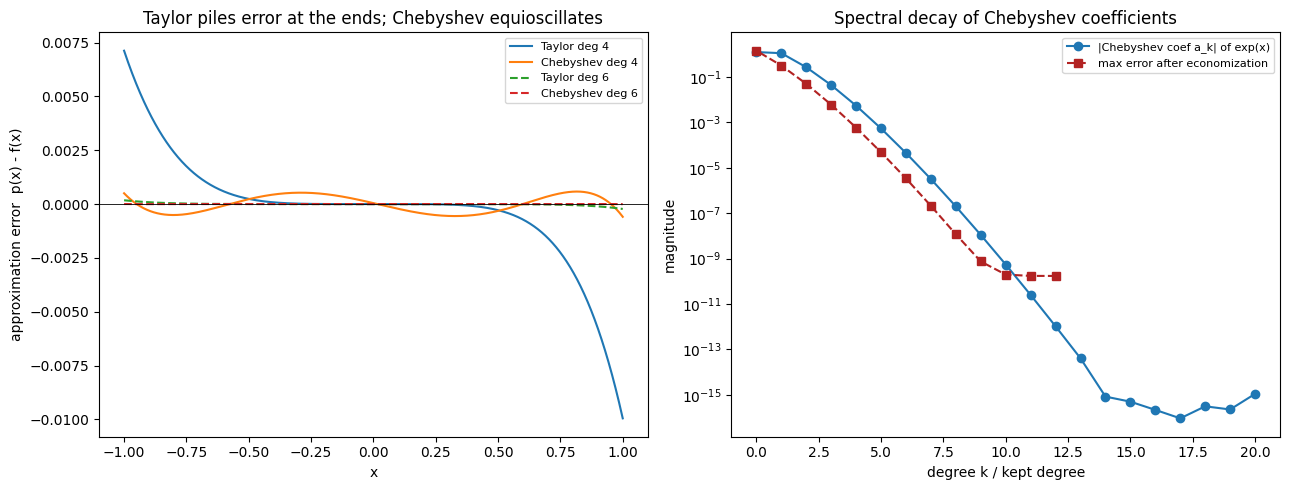

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# (좌) 오차 곡선: 테일러는 끝점 폭증, 체비쇼프는 equioscillation
for n, style in [(4, "-"), (6, "--")]:
    ax[0].plot(xx, taylor_eval(n, xx) - fx, style, lw=1.5, label=f"Taylor deg {n}")
    ax[0].plot(xx, cheb_trunc_eval(n, xx) - fx, style, lw=1.5, label=f"Chebyshev deg {n}")
ax[0].axhline(0, color="k", lw=0.6)
ax[0].set_xlabel("x"); ax[0].set_ylabel("approximation error  p(x) - f(x)")
ax[0].set_title("Taylor piles error at the ends; Chebyshev equioscillates")
ax[0].legend(fontsize=8)

# (우) 체비쇼프 계수의 빠른 감소 + 경제화 오차 증가
ks = np.arange(len(a_full))
ax[1].semilogy(ks, np.abs(a_full) + 1e-20, "o-", label="|Chebyshev coef a_k| of exp(x)")
ax[1].semilogy(econ_df["kept degree"], econ_df["max|err| after drop"], "s--",
               color="firebrick", label="max error after economization")
ax[1].set_xlabel("degree k / kept degree"); ax[1].set_ylabel("magnitude")
ax[1].set_title("Spectral decay of Chebyshev coefficients")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **끝점 vs 균등**: 테일러 오차는 $x=\pm1$ 에서 가장 크게 부풀지만(전개점 $x=0$ 에서 멀어질수록 악화), 체비쇼프
   오차는 구간 전체에서 비슷한 크기로 **진동(equioscillation)** 한다. 같은 차수에서 체비쇼프의 *최대*오차가 훨씬 작다.
2. **near-minimax**: 표의 `Taylor/Cheb ratio` 가 차수에 따라 커진다 — 체비쇼프 절단이 진짜 최선(minimax) 근사에
   가깝다는 증거다. 이는 $\tilde T_n=2^{-(n-1)}T_n$ 의 minimax 성질의 직접적 귀결이다.
3. **경제화의 실익**: 체비쇼프 계수 $|a_k|$ 가 급감하므로, 최고차 항을 몇 개 버려도 최대오차는 버린 계수 크기만큼만
   완만히 증가한다. 즉 차수를 낮춰 연산을 줄이면서도 정확도를 *예측 가능하게* 통제할 수 있다.

### 결론
> **체비쇼프 절단은 오차를 구간 전체에 균등 분산시켜 같은 차수에서 테일러보다 최대오차가 훨씬 작은 near-minimax
> 근사를 준다. 계수의 빠른 감소 덕분에 *경제화* 로 차수를 안전하게 줄일 수 있다.**

### 다음 문제 연결
- **CE 9.2.3**: 모델이 **계수에 대해 비선형**이면 정규방정식이 닫힌 형태로 풀리지 않는다 — **가우스–뉴턴 / 레벤버그–
  마쿼트** 반복으로 비선형 최소제곱을 풀고, 댐핑이 발산을 어떻게 막는지 본다.